## 1. IMPORT

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## 2. ĐỌC DỮ LIỆU

In [26]:
customer = pd.read_csv('../data/customer.csv')
df_success = pd.read_csv('../data/df_success.csv')
customer.head()

,Customer ID,Country,Recency,Monetary,Frequency
0,12346.0,United Kingdom,165,372.86,11
1,12347.0,Iceland,3,1323.32,2
2,12348.0,Finland,74,222.16,1
3,12349.0,Italy,43,2671.14,3
4,12351.0,Unspecified,11,300.93,1


In [27]:
df_success.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [28]:
df_success['InvoiceDate'] = pd.to_datetime(df_success['InvoiceDate'])

## 3. TẠO FEATURE CHO 6 THÁNG ĐẦU

In [29]:
now = df_success['InvoiceDate'].max() + pd.Timedelta(days=1)
six_months_ago = now - pd.Timedelta(days=180)

In [30]:
# Dữ liệu 6 tháng đầu (training)
first_6_months = df_success[df_success['InvoiceDate'] < six_months_ago]

rfm_train = first_6_months.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (now - x.max()).days,
    'Amount': 'sum',
    'Invoice': 'nunique',
    'Quantity': 'mean',
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Amount': 'Monetary',
    'Frequency': 'Invoice',
    'Quantity': 'Avg_Quantity',
    'Price': 'Avg_Price'
})

In [31]:
# Feature: Average days between purchases
first_6_months['InvoiceDate_shift'] = first_6_months.groupby('Customer ID')['InvoiceDate'].shift(1)
first_6_months['Days_Between'] = (first_6_months['InvoiceDate'] - first_6_months['InvoiceDate_shift']).dt.days
avg_days_between = first_6_months.groupby('Customer ID')['Days_Between'].mean()
rfm_train['Avg_Days_Between'] = avg_days_between

In [32]:
# Feature: Number of unique products
unique_products = first_6_months.groupby('Customer ID')['StockCode'].nunique()
rfm_train['Unique_Products'] = unique_products

In [33]:
# Feature: Country information
country_for_customer = df_success.groupby('Customer ID')['Country'].first()
rfm_train['Country'] = country_for_customer

country_stats = first_6_months.groupby('Country').agg({
    'Amount': 'mean',
    'Invoice': lambda x: x.nunique() / len(x.unique())
}).rename(columns={
    'Amount': 'Country_Monetary_Avg',
    'Invoice': 'Country_Frequency_Avg'
})

In [34]:
# Merge country stats
country_for_customer = first_6_months.groupby('Customer ID')['Country'].first()
rfm_train['Country'] = country_for_customer
rfm_train = rfm_train.merge(country_stats, left_on='Country', right_index=True, how='left')
rfm_train = rfm_train.drop('Country', axis=1)
rfm_train.head()

,Recency,Monetary,Invoice,Avg_Quantity,Avg_Days_Between,Unique_Products,Country_Monetary_Avg,Country_Frequency_Avg
Customer ID,,,,,,,,
12346.0,283,230.55,10,3.642857,5.692308,7,20.190907,1.0
12349.0,206,1268.52,2,10.085106,0.391304,47,17.558557,1.0
12355.0,203,488.21,1,13.772727,0.000000,22,22.191364,1.0
12358.0,186,1697.93,2,16.857143,5.323529,34,28.995459,1.0
12359.0,262,1522.23,4,11.772727,1.630769,65,23.751303,1.0


## 4. TẠO TARGET (6 THÁNG CUỐI)

In [47]:
last_6_months = df_success[df_success['InvoiceDate'] >= six_months_ago]
target_raw = last_6_months.groupby('Customer ID')['Amount'].sum()

# Giữ lại toàn bộ khách hàng, gán 0 cho người không mua
target = target_raw.reindex(rfm_train.index).fillna(0)

churn_count = (target == 0).sum()
print(f"Tổng số khách hàng: {len(target)}")
print(f"Số khách hàng đã churn: {churn_count} ({churn_count/len(target)*100:.1f}%)")
print(f"Số khách hàng active: {len(target) - churn_count}")

Tổng số khách hàng: 2830
Số khách hàng đã churn: 833 (29.4%)
Số khách hàng active: 1997


## 5. XỬ LÝ FEATURE

In [36]:
# Fill missing Avg_Days_Between (khách hàng chỉ mua 1 lần)
rfm_train['Avg_Days_Between'] = rfm_train['Avg_Days_Between'].fillna(365)

## 6. CHUẨN BỊ DỮ LIỆU CHO MODEL

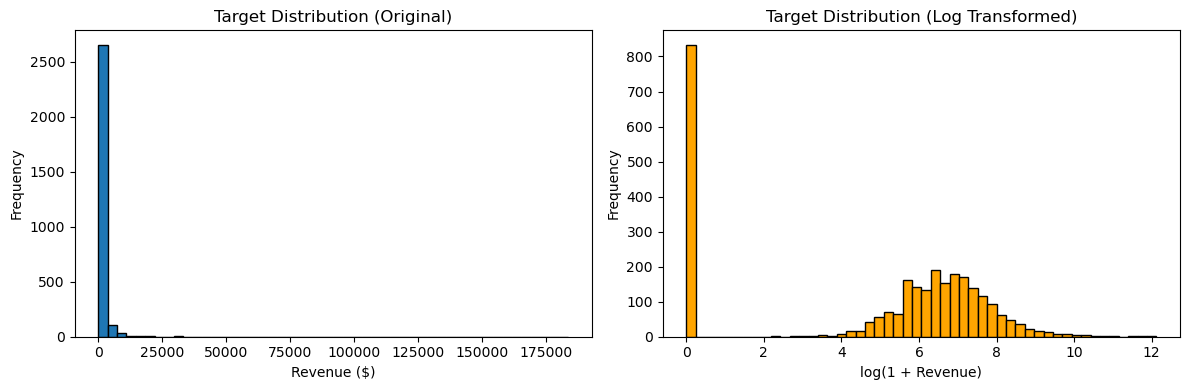


Target stats (Original):
  Mean: $1343.18
  Median: $420.95
  Max: $183702.18
  % Khách hàng có doanh thu = 0: 29.4%


In [37]:
X = rfm_train.copy()
y = target.copy()

# Log transform cho target 
y_log = np.log1p(y) 

# Visualize phân phối target trước và sau khi log
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(y, bins=50, edgecolor='black')
ax1.set_title('Target Distribution (Original)')
ax1.set_xlabel('Revenue ($)')
ax1.set_ylabel('Frequency')

ax2.hist(y_log, bins=50, edgecolor='black', color='orange')
ax2.set_title('Target Distribution (Log Transformed)')
ax2.set_xlabel('log(1 + Revenue)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"\nTarget stats (Original):")
print(f"  Mean: ${y.mean():.2f}")
print(f"  Median: ${y.median():.2f}")
print(f"  Max: ${y.max():.2f}")
print(f"  % Khách hàng có doanh thu = 0: {(y == 0).sum() / len(y) * 100:.1f}%")

## 7. CHIA TRAIN/TEST

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42, stratify=(y == 0))

## 8. SCALE FEATURE

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 9. TRAIN VÀ SO SÁNH CÁC MODEL

In [40]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
}

In [48]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_log = model.predict(X_test_scaled)
    
    # Chuyển về scale gốc để đánh giá
    y_pred = np.expm1(y_pred_log)
    y_test_original = np.expm1(y_test)
    
    r2 = r2_score(y_test_original, y_pred)
    mae = mean_absolute_error(y_test_original, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
    
    results[name] = {
        'R2 Score': r2,
        'MAE ($)': mae,
        'RMSE ($)': rmse
    }

## 10. HIỂN THỊ KẾT QUẢ

In [42]:
results_df = pd.DataFrame(results).T
print("\nKẾT QUẢ ĐÁNH GIÁ MODEL:")
print(results_df.round(2))


KẾT QUẢ ĐÁNH GIÁ MODEL:
                     R2 Score    MAE ($)    RMSE ($)
Linear Regression -1602913.12  274050.01  6066875.30
Random Forest            0.83     839.04     1995.83
Gradient Boosting        0.73     914.97     2510.73


## 11. CHỌN MODEL TỐT NHẤT

In [43]:
best_model_name = results_df['R2 Score'].idxmax()
best_model = models[best_model_name]
print(f"\nModel tốt nhất: {best_model_name}")
print(f"R2 Score: {results_df.loc[best_model_name, 'R2 Score']:.4f}")
print(f"RMSE: ${results_df.loc[best_model_name, 'RMSE ($)']:.2f}")


Model tốt nhất: Random Forest
R2 Score: 0.8265
RMSE: $1995.83


## 12. FEATURE IMPORTANCE


TOP FEATURE QUAN TRỌNG NHẤT:
                 Feature  Importance
1               Monetary    0.436024
0                Recency    0.158398
3           Avg_Quantity    0.146371
5        Unique_Products    0.121063
4       Avg_Days_Between    0.075652
2                Invoice    0.040517
6   Country_Monetary_Avg    0.021975
7  Country_Frequency_Avg    0.000000


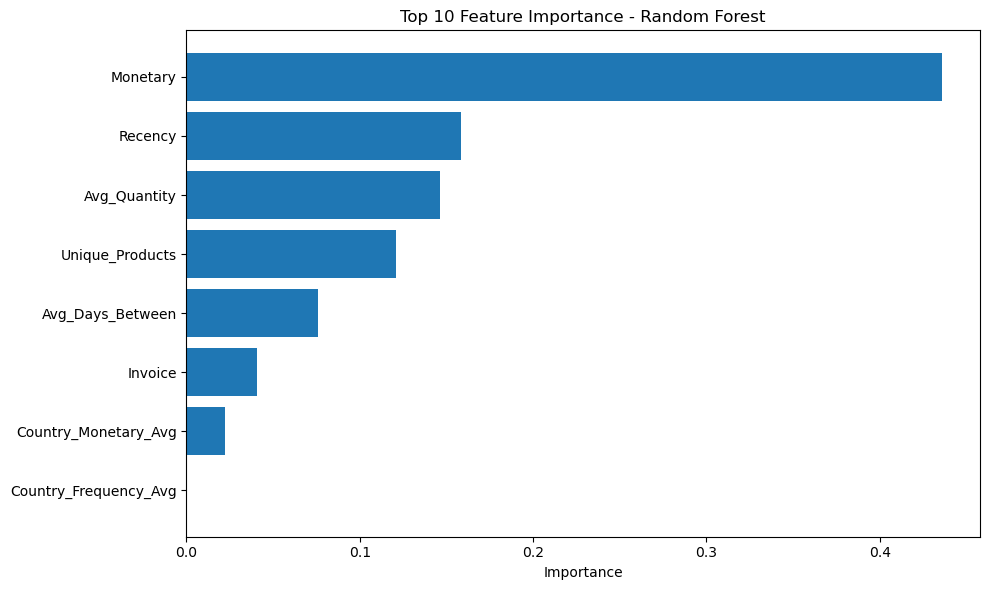

In [44]:
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTOP FEATURE QUAN TRỌNG NHẤT:")
    print(feature_importance.head(10))
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 13. LƯU MODEL

In [45]:
import joblib

artifacts = {
    'model': best_model,
    'scaler': scaler,
    'feature_names': X.columns.tolist(),
    'model_name': best_model_name,
    'target_transformer': 'log1p' 
}

joblib.dump(artifacts, '../models/regressor_model.pkl')
print("\nĐã lưu model vào 'models/regressor_model.pkl'")


Đã lưu model vào 'models/regressor_model.pkl'


## 14. KIỂM TRA MODEL TRÊN TEST SET`

KIỂM TRA DỰ ĐOÁN TRÊN TEST SET

So sánh 10 khách hàng ngẫu nhiên:
      Actual  Predicted
409  1022.83     137.54
234   607.75      78.33
506  1486.91    1189.13
145   312.54      96.54
454   406.60       8.05
474   111.11      66.05
284     0.00       9.12
93      0.00     190.72
128   867.48     130.25
337     0.00      89.28
PHÂN TÍCH SAI SỐ THEO NHÓM DOANH THU
                      mean      std  count
Revenue_Group                             
Low (0-100)          97.12   203.48    173
Medium (100-1000)  -256.58   460.14    229
High (>1000)      -2067.92  3014.43    164


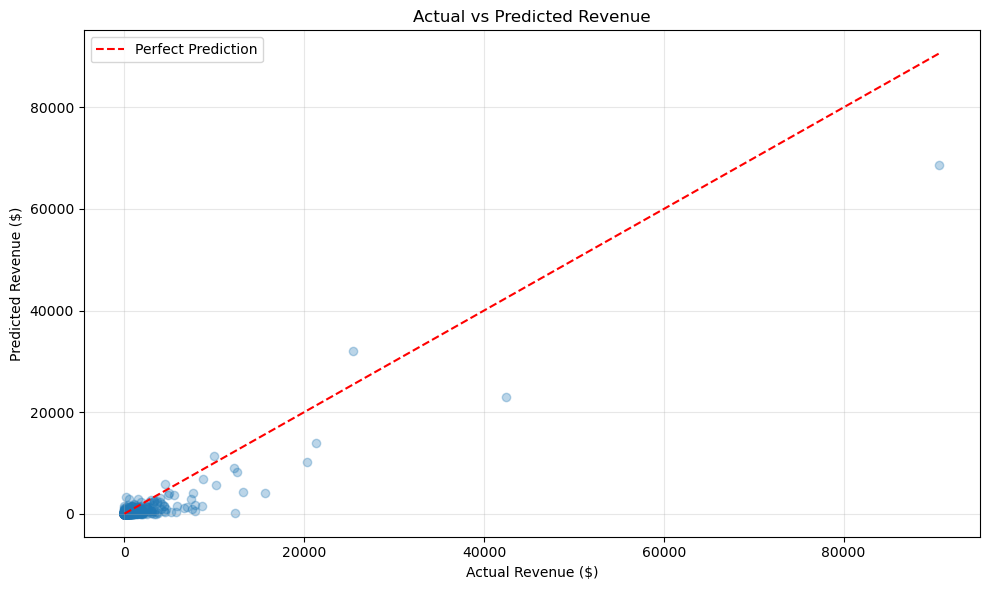


 Model dự đoán tốt nhất cho nhóm: High (>1000)
   Sai số trung bình: $-2067.92


In [46]:
y_pred_log = best_model.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# So sánh dự đoán vs thực tế
compare_df = pd.DataFrame({
    'Actual': y_test_original,
    'Predicted': y_pred
}).reset_index(drop=True)

print("KIỂM TRA DỰ ĐOÁN TRÊN TEST SET")

# Lấy 10 mẫu ngẫu nhiên để so sánh
sample_compare = compare_df.sample(10)
print("\nSo sánh 10 khách hàng ngẫu nhiên:")
print(sample_compare.round(2))

# Phân tích sai số theo từng nhóm doanh thu
compare_df['Error'] = compare_df['Predicted'] - compare_df['Actual']
compare_df['Error_Pct'] = (compare_df['Error'] / (compare_df['Actual'] + 1)) * 100

print("PHÂN TÍCH SAI SỐ THEO NHÓM DOANH THU")

# Chia thành 3 nhóm: Low, Medium, High
compare_df['Revenue_Group'] = pd.cut(
    compare_df['Actual'], 
    bins=[-1, 100, 1000, float('inf')], 
    labels=['Low (0-100)', 'Medium (100-1000)', 'High (>1000)']
)

error_by_group = compare_df.groupby('Revenue_Group')['Error'].agg(['mean', 'std', 'count'])
print(error_by_group.round(2))

# Vẽ biểu đồ Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(compare_df['Actual'], compare_df['Predicted'], alpha=0.3)
plt.plot([0, compare_df['Actual'].max()], [0, compare_df['Actual'].max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Revenue ($)')
plt.ylabel('Predicted Revenue ($)')
plt.title('Actual vs Predicted Revenue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Model dự đoán tốt nhất cho nhóm: {error_by_group['mean'].idxmin()}")
print(f"   Sai số trung bình: ${error_by_group.loc[error_by_group['mean'].idxmin(), 'mean']:.2f}")